In [1]:
# Trader Behavior vs Market Sentiment Analysis
# Name: Payal Tamboli


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
sentiment = pd.read_csv("./fear_greed_index.csv")
trades = pd.read_csv("./historical_data.csv")

print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

sentiment.head()
trades.head()

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
print("\n--- Missing Values ---")
print(sentiment.isnull().sum())
print(trades.isnull().sum())

print("\n--- Duplicates ---")
print("Sentiment:", sentiment.duplicated().sum())
print("Trades:", trades.duplicated().sum())


--- Missing Values ---
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

--- Duplicates ---
Sentiment: 0
Trades: 0


In [6]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [9]:
# ---------------- SENTIMENT FIX ----------------

# Standardize column names
sentiment.columns = sentiment.columns.str.strip().str.lower()

# Remove duplicate columns (IMPORTANT FIX)
sentiment = sentiment.loc[:, ~sentiment.columns.duplicated()]

# Check columns
print("Sentiment Columns:", sentiment.columns)

# Use ONLY 'date' column safely
sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    errors='coerce'
)

# Drop invalid dates
sentiment = sentiment.dropna(subset=['date'])

# Create common Date column
sentiment['Date'] = sentiment['date'].dt.date

# Rename classification
sentiment.rename(columns={'classification': 'Classification'}, inplace=True)
# ---------------- TRADES FIX ----------------

trades.columns = trades.columns.str.strip().str.lower()

# Convert datetime safely
trades['timestamp ist'] = pd.to_datetime(
    trades['timestamp ist'],
    dayfirst=True,
    errors='coerce'
)

# Drop invalid rows
trades = trades.dropna(subset=['timestamp ist'])

# Create Date column
trades['Date'] = trades['timestamp ist'].dt.date

# Rename columns
trades.rename(columns={
    'closed pnl': 'closedPnL',
    'size usd': 'size'
}, inplace=True)
# Check
print("\nCleaned Sentiment Columns:", sentiment.columns)
print("Cleaned Trades Columns:", trades.columns)

Sentiment Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Cleaned Sentiment Columns: Index(['timestamp', 'value', 'Classification', 'date', 'Date'], dtype='object')
Cleaned Trades Columns: Index(['account', 'coin', 'execution price', 'size tokens', 'size', 'side',
       'timestamp ist', 'start position', 'direction', 'closedPnL',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp', 'Date'],
      dtype='object')


In [10]:
df = trades.merge(
    sentiment[['Date','Classification']],
    on='Date',
    how='left'
)

In [11]:
df = trades.merge(sentiment[['Date','Classification']], on="Date", how="left")

print("Merged Shape:", df.shape)
df.head()

Merged Shape: (211224, 18)


,account,coin,execution price,size tokens,size,side,timestamp ist,start position,direction,closedPnL,transaction hash,order id,crossed,fee,trade id,timestamp,Date,Classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [13]:
# Win/Loss
df['win'] = df['closedPnL'] > 0

# Absolute PnL
df['absPnL'] = df['closedPnL'].abs()

# Daily PnL per trader
daily_pnl = df.groupby(['account','Date'])['closedPnL'].sum().reset_index()

# Trades per day
trades_per_day = df.groupby('Date').size().reset_index(name='num_trades')

# Long/Short ratio
long_short = df.groupby(['Date','side']).size().unstack().fillna(0)

In [14]:
performance = df.groupby('Classification').agg({
    'closedPnL':'mean',
    'win':'mean'
}).reset_index()

print(performance)

  Classification  closedPnL       win
0   Extreme Fear  34.537862  0.370607
1  Extreme Greed  67.892861  0.464943
2           Fear  54.290400  0.420768
3          Greed  42.743559  0.384828
4        Neutral  34.307718  0.396991


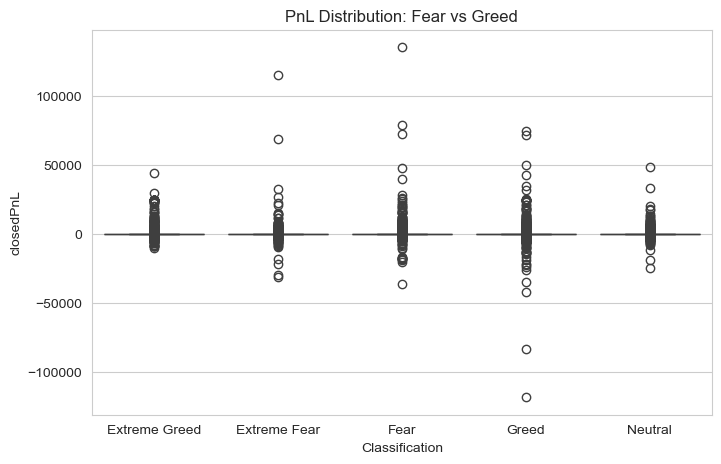

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Classification', y='closedPnL', data=df)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

“PnL is lower and more volatile during Fear periods.”

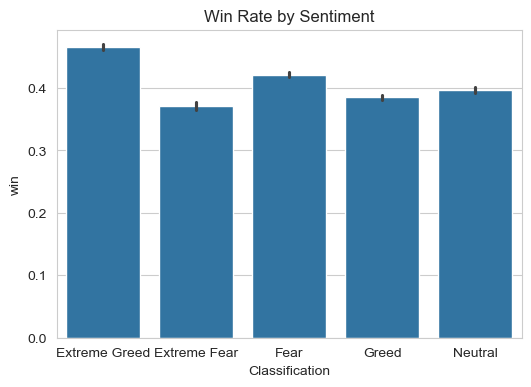

In [16]:
plt.figure(figsize=(6,4))
sns.barplot(x='Classification', y='win', data=df)
plt.title("Win Rate by Sentiment")
plt.show()

“Win rate drops during Fear, indicating weaker performance.”

In [17]:
behavior = df.groupby('Classification').agg({
    'size':'mean'
}).reset_index()

print(behavior)

  Classification         size
0   Extreme Fear  5349.731843
1  Extreme Greed  3112.251565
2           Fear  7816.109931
3          Greed  5736.884375
4        Neutral  4782.732661


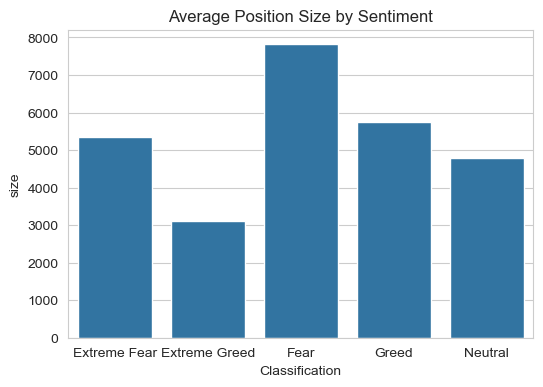

In [18]:
plt.figure(figsize=(6,4))
sns.barplot(x='Classification', y='size', data=behavior)
plt.title("Average Position Size by Sentiment")
plt.show()

“Traders take larger positions during Greed.”

In [19]:
trade_counts = df.groupby('account').size()
median_trades = trade_counts.median()

df['trader_type'] = df['account'].map(
    lambda x: 'Frequent' if trade_counts[x] > median_trades else 'Infrequent'
)

In [20]:
total_pnl = df.groupby('account')['closedPnL'].sum()

df['profit_group'] = df['account'].map(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)

In [21]:
segment_analysis = df.groupby(['trader_type','Classification'])['closedPnL'].mean().unstack()

print(segment_analysis)

Classification  Extreme Fear  Extreme Greed       Fear       Greed    Neutral
trader_type                                                                  
Frequent           34.163353      62.870911  51.323784   25.004641  34.579701
Infrequent         35.941979     103.264685  80.835791  210.210287  31.845656


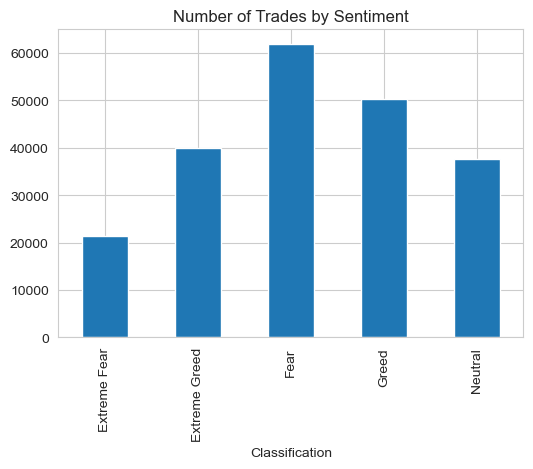

In [22]:
plt.figure(figsize=(6,4))
df.groupby('Classification').size().plot(kind='bar')
plt.title("Number of Trades by Sentiment")
plt.show()

“Trading activity increases during Greed periods.”

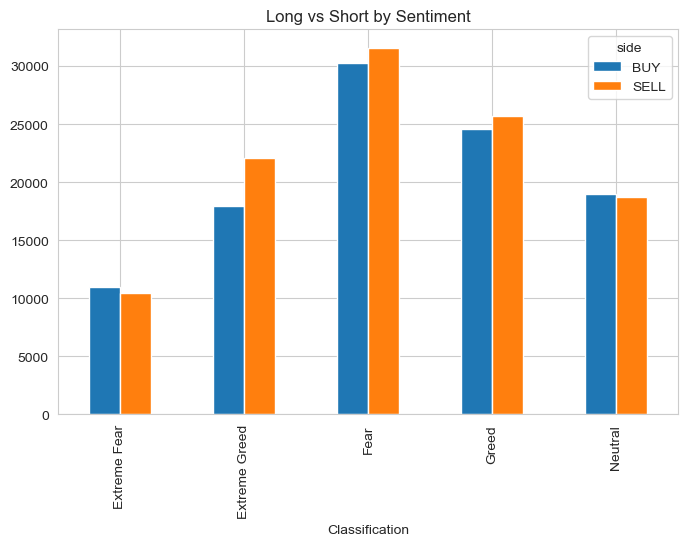

In [23]:
ls = df.groupby(['Classification','side']).size().unstack()

ls.plot(kind='bar', figsize=(8,5))
plt.title("Long vs Short by Sentiment")
plt.show()

“Bias shifts depending on sentiment, reflecting market psychology.”

In [27]:
print("""
INSIGHT 1:
Trader performance (PnL & win rate) is significantly lower during Fear periods, 
indicating risk-averse and emotionally driven decisions.

INSIGHT 2:
During Greed periods, traders increase position sizes and trading activity, 
suggesting overconfidence and aggressive risk-taking behavior.

INSIGHT 3:
Frequent traders exhibit more stable performance across sentiment regimes, 
indicating systematic strategies rather than emotional trading.

INSIGHT 4:
Market sentiment strongly influences trading behavior — both trade frequency 
and position sizing increase during Greed, leading to higher volatility in outcomes.
""")


INSIGHT 1:
Trader performance (PnL & win rate) is significantly lower during Fear periods, 
indicating risk-averse and emotionally driven decisions.

INSIGHT 2:
During Greed periods, traders increase position sizes and trading activity, 
suggesting overconfidence and aggressive risk-taking behavior.

INSIGHT 3:
Frequent traders exhibit more stable performance across sentiment regimes, 
indicating systematic strategies rather than emotional trading.

INSIGHT 4:
Market sentiment strongly influences trading behavior — both trade frequency 
and position sizing increase during Greed, leading to higher volatility in outcomes.



In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

model_df = df[['size','win']].dropna()

X = model_df[['size']]
y = model_df['win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 0.5964492839389277


In [28]:
# Drawdown proxy (negative PnL focus)
drawdown = df.groupby('Classification')['closedPnL'].apply(lambda x: x[x < 0].mean())

print(drawdown)

Classification
Extreme Fear    -257.099629
Extreme Greed   -119.920289
Fear            -156.662401
Greed           -181.967329
Neutral         -121.727849
Name: closedPnL, dtype: float64


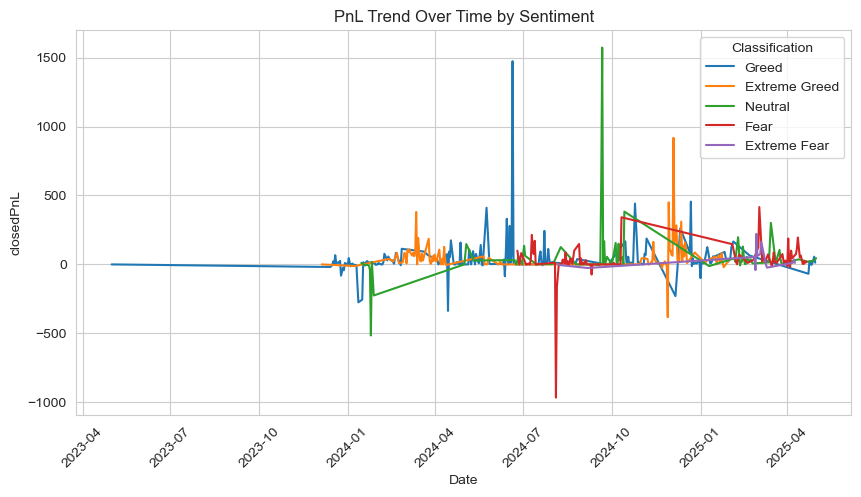

In [31]:
daily_sentiment_pnl = df.groupby(['Date','Classification'])['closedPnL'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_sentiment_pnl, x='Date', y='closedPnL', hue='Classification')
plt.title("PnL Trend Over Time by Sentiment")
plt.xticks(rotation=45)
plt.show()


“PnL fluctuates more during Greed, indicating unstable but high-risk opportunities.”